In [2]:
import kagglehub
path = kagglehub.dataset_download("chirin/africa-economic-banking-and-systemic-crisis-data")

Using Colab cache for faster access to the 'africa-economic-banking-and-systemic-crisis-data' dataset.


In [3]:
import os
import pandas as pd

# List files in the downloaded path to identify the CSV file
files = os.listdir(path)
print(f"Files in the dataset directory: {files}")

# Assuming the main data is in a CSV file, let's find it.
# This might need adjustment based on the actual file names.
csv_file = [f for f in files if f.endswith('.csv')][0] if any(f.endswith('.csv') for f in files) else None

if csv_file:
    data_path = os.path.join(path, csv_file)
    print(f"Loading data from: {data_path}")
    df = pd.read_csv(data_path)
    print("Data loaded successfully.")
    display(df.head())
else:
    print("No CSV file found in the dataset directory.")

Files in the dataset directory: ['african_crises.csv']
Loading data from: /kaggle/input/africa-economic-banking-and-systemic-crisis-data/african_crises.csv
Data loaded successfully.


,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


Now that the data is loaded, let's perform some initial exploratory data analysis (EDA) to understand its characteristics, such as column types, missing values, and basic statistics. This will inform our preprocessing steps.

In [4]:
# Display basic information about the DataFrame
display(df.info())

# Display descriptive statistics of numerical columns
display(df.describe())

# Check for missing values
display(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

None

,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000,1059.000000,1059.000000
mean,35.613787,1967.767705,0.077432,43.140831,0.039660,0.152975,0.006402,2.084889e+04,0.776204,0.132200,0.129367
std,23.692402,33.530632,0.267401,111.475380,0.195251,0.360133,0.043572,6.757274e+05,0.416984,0.349847,0.335765
min,1.000000,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.850214e+01,0.000000,0.000000,0.000000
25%,15.000000,1951.000000,0.000000,0.195350,0.000000,0.000000,0.000000,2.086162e+00,1.000000,0.000000,0.000000
50%,38.000000,1973.000000,0.000000,0.868400,0.000000,0.000000,0.000000,5.762330e+00,1.000000,0.000000,0.000000
75%,56.000000,1994.000000,0.000000,8.462750,0.000000,0.000000,0.000000,1.164405e+01,1.000000,0.000000,0.000000
max,70.000000,2014.000000,1.000000,744.306139,1.000000,1.000000,0.400000,2.198970e+07,1.000000,2.000000,1.000000


,0


### Data Preprocessing for Deep Learning

Based on the EDA, we need to preprocess the data before feeding it into a deep learning model. This typically involves:
1.  **Defining the target variable**: We'll use `banking_crisis` as our target, as it represents the crisis status.
2.  **Encoding categorical features**: Convert 'banking_crisis' and other categorical columns (`cc3`, `country`) into numerical representations.
3.  **Splitting data**: Separate the dataset into features (X) and target (y).
4.  **Train-test split**: Divide the data into training and testing sets.
5.  **Scaling numerical features**: Normalize or standardize numerical features, which can improve model performance.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Define target variable
y = df['banking_crisis']
X = df.drop('banking_crisis', axis=1)

# Encode the target variable if it's categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a preprocessing pipeline for numerical and categorical features
# Use OneHotEncoder for categorical features and StandardScaler for numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a preprocessing pipeline for the entire dataset
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply preprocessing to features
X_processed = pipeline.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Classes and their encoded values: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Shape of X_train: (847, 37)
Shape of X_test: (212, 37)
Shape of y_train: (847,)
Shape of y_test: (212,)
Classes and their encoded values: [('crisis', np.int64(0)), ('no_crisis', np.int64(1))]


### Build a Deep Learning Model

Now that our data is preprocessed and split, let's define and build a deep learning model using TensorFlow/Keras. Since this is a multi-class classification problem (if `banking_crisis` has more than two unique values, which it seems to have: 'crisis', 'no_crisis'), we'll use a sequential model with dense layers and a softmax activation function for the output layer.

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Convert integer labels to one-hot encoded vectors for Keras
# This is necessary for multi-class classification with 'categorical_crossentropy'
num_classes = len(label_encoder.classes_)
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,250 (51.76 KB)

 Trainable params: 13,250 (51.76 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Deep Learning Model

With the model defined and compiled, we can now train it using our preprocessed training data. We'll also use a portion of the training data as validation data to monitor overfitting.

In [7]:
history = model.fit(X_train, y_train_one_hot,
                    epochs=50,  # You can adjust the number of epochs
                    batch_size=32,
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8154 - loss: 0.4795 - val_accuracy: 0.9000 - val_loss: 0.2761
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9247 - loss: 0.2083 - val_accuracy: 0.9588 - val_loss: 0.1392
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9616 - loss: 0.1383 - val_accuracy: 0.9765 - val_loss: 0.0948
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9690 - loss: 0.1172 - val_accuracy: 0.9765 - val_loss: 0.0781
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9705 - loss: 0.1023 - val_accuracy: 0.9824 - val_loss: 0.0720
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9734 - loss: 0.1020 - val_accuracy: 0.9824 - val_loss: 0.0686
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9734 - loss: 0.0930 - val_accuracy: 0.9824 - val_loss: 0.0669
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9675 - loss: 0.0963 - val_accuracy: 0.9824 - val_loss

### Visualize Training History

To better understand our model's performance and detect potential overfitting, let's plot the training and validation accuracy and loss over the epochs.

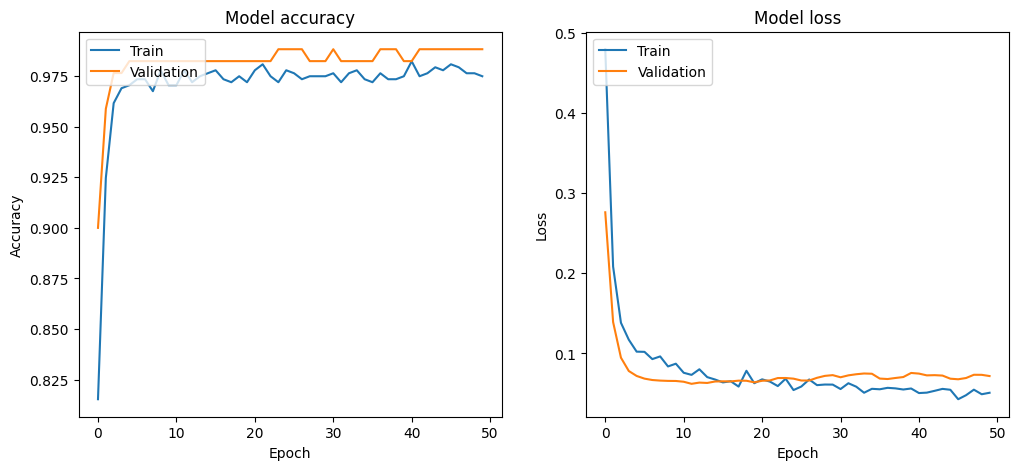

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


### Confusion Matrix and Classification Report

To further evaluate the model's performance, especially for classification tasks, let's generate a confusion matrix and a classification report. This will provide detailed metrics like precision, recall, and F1-score for each class.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


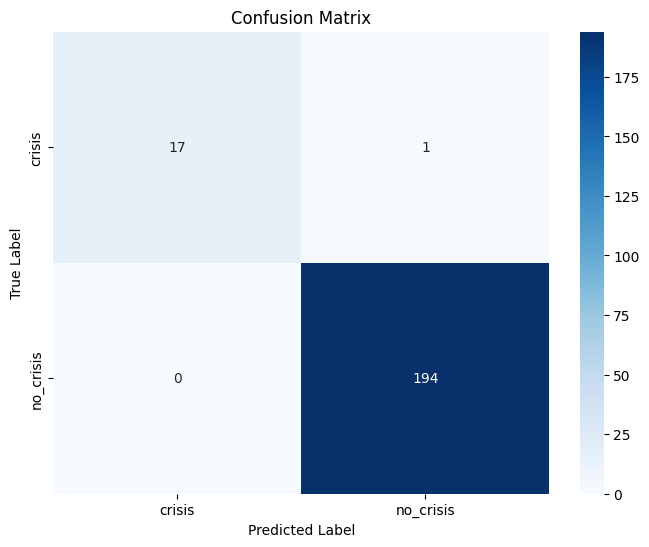

Classification Report:
              precision    recall  f1-score   support

      crisis       1.00      0.94      0.97        18
   no_crisis       0.99      1.00      1.00       194

    accuracy                           1.00       212
   macro avg       1.00      0.97      0.98       212
weighted avg       1.00      1.00      1.00       212



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions from the model
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate classification report
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("Classification Report:")
print(class_report)

### Save Model and Preprocessing Components

To use the trained model and its preprocessing steps in a Streamlit application (or any other external script), we need to save them. We'll save the Keras model directly and use `joblib` to save the `pipeline` (which contains our `ColumnTransformer`) and the `label_encoder`.

In [10]:
import joblib

# Save the Keras model
model.save('banking_crisis_model.h5')
print('Keras model saved as banking_crisis_model.h5')

# Save the preprocessing pipeline
joblib.dump(pipeline, 'preprocessor_pipeline.pkl')
print('Preprocessing pipeline saved as preprocessor_pipeline.pkl')

# Save the label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')
print('Label encoder saved as label_encoder.pkl')

Keras model saved as banking_crisis_model.h5
Preprocessing pipeline saved as preprocessor_pipeline.pkl
Label encoder saved as label_encoder.pkl


### Create Streamlit Application (app.py)

Below is the code for a Streamlit application (`app.py`) that will allow you to input new data and get predictions from your deep learning model. It loads the saved model and preprocessing components to ensure consistency.

In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

# Load the saved model and preprocessing components
@st.cache_resource
def load_model_and_preprocessor():
    model = tf.keras.models.load_model('banking_crisis_model.h5')
    pipeline = joblib.load('preprocessor_pipeline.pkl')
    label_encoder = joblib.load('label_encoder.pkl')
    return model, pipeline, label_encoder

model, pipeline, label_encoder = load_model_and_preprocessor()

# Get the original DataFrame to extract column information for input fields
# This assumes 'df' was saved or can be recreated with initial data.
# For a true deployed app, you'd load a schema or a small sample of the original data.
# For this demonstration, we'll recreate a dummy df structure for column names and types.
# In a real scenario, you would have saved df.columns and df.dtypes.

# Based on the kernel state, let's infer the original columns and their types
# This part needs to be robust for deployment, e.g., saving X.columns during training.
original_df_columns = ['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd',
                       'domestic_debt_in_default', 'sovereign_external_debt_default',
                       'gdp_weighted_default', 'inflation_annual_cpi', 'independence',
                       'currency_crises', 'inflation_crises']

# Set up Streamlit interface
st.title('Banking Crisis Prediction App')
st.write('Enter the features below to predict the likelihood of a banking crisis.')

# Create input fields for each feature (simplified for demonstration)
input_data = {}

# Numerical inputs
input_data['case'] = st.number_input('Case ID (e.g., 1)', value=1, step=1)
input_data['year'] = st.number_input('Year (e.g., 1870)', value=1990, step=1)
input_data['exch_usd'] = st.number_input('Exchange Rate USD (e.g., 0.05)', value=1.0, format="%.6f")
input_data['inflation_annual_cpi'] = st.number_input('Annual CPI Inflation (e.g., 3.44)', value=5.0, format="%.6f")
input_data['gdp_weighted_default'] = st.number_input('GDP Weighted Default (e.g., 0.0)', value=0.0, format="%.6f")

# Binary inputs
input_data['systemic_crisis'] = st.selectbox('Systemic Crisis (0=No, 1=Yes)', options=[0, 1])
input_data['domestic_debt_in_default'] = st.selectbox('Domestic Debt in Default (0=No, 1=Yes)', options=[0, 1])
input_data['sovereign_external_debt_default'] = st.selectbox('Sovereign External Debt Default (0=No, 1=Yes)', options=[0, 1])
input_data['independence'] = st.selectbox('Independence (0=No, 1=Yes)', options=[0, 1])
input_data['currency_crises'] = st.selectbox('Currency Crises (0=No, 1=Yes)', options=[0, 1, 2]) # max was 2
input_data['inflation_crises'] = st.selectbox('Inflation Crises (0=No, 1=Yes)', options=[0, 1])

# Categorical inputs (example with a few options, in a real app you'd get all unique values)
# For 'cc3' and 'country', providing a limited set for demo. In a real app, you'd load these.
input_data['cc3'] = st.selectbox('Country Code (e.g., DZA, AGO, BFA)', options=['DZA', 'AGO', 'BFA', 'CAF', 'CPV', 'CMR', 'CIV', 'EGY', 'ERI', 'ETH', 'GMB', 'GHA', 'GIN', 'GNB', 'LBR', 'LBY', 'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SLE', 'SOM', 'ZAF', 'SDN', 'TZA', 'TGO', 'TUN', 'UGA', 'ZAR', 'ZMB', 'ZWE'])
input_data['country'] = st.selectbox('Country Name (e.g., Algeria, Angola)', options=['Algeria', 'Angola', 'Burkina Faso', 'Central African Republic', 'Cape Verde', 'Cameroon', 'Cote d\'Ivoire', 'Egypt', 'Eritrea', 'Ethiopia', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Liberia', 'Libya', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Somalia', 'South Africa', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zaire', 'Zambia', 'Zimbabwe'])


if st.button('Predict Banking Crisis'):
    # Create a DataFrame from input data, ensuring correct column order
    input_df = pd.DataFrame([input_data])

    # Ensure all original columns are present and in the correct order
    # This is critical if the pipeline expects a certain order/set of columns
    missing_cols = set(original_df_columns) - set(input_df.columns)
    for c in missing_cols:
        input_df[c] = 0 # or some other appropriate default/placeholder
    input_df = input_df[original_df_columns] # Reorder columns

    # Preprocess the input data
    processed_input = pipeline.transform(input_df)

    # Make prediction
    prediction_proba = model.predict(processed_input)
    prediction_class_index = np.argmax(prediction_proba, axis=1)[0]
    prediction_label = label_encoder.inverse_transform([prediction_class_index])[0]

    st.subheader(f'Prediction: **{prediction_label.replace("_", " ").title()}**')
    st.write(f'Confidence (Probability of {prediction_label.replace("_", " ").title()}): {prediction_proba[0][prediction_class_index]:.4f}')


Writing app.py


In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

# Load the saved model and preprocessing components
@st.cache_resource
def load_model_and_preprocessor():
    model = tf.keras.models.load_model('banking_crisis_model.h5')
    pipeline = joblib.load('preprocessor_pipeline.pkl')
    label_encoder = joblib.load('label_encoder.pkl')
    return model, pipeline, label_encoder

model, pipeline, label_encoder = load_model_and_preprocessor()

# Get the original DataFrame to extract column information for input fields
original_df_columns = ['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd',
                       'domestic_debt_in_default', 'sovereign_external_debt_default',
                       'gdp_weighted_default', 'inflation_annual_cpi', 'independence',
                       'currency_crises', 'inflation_crises']

# --- Streamlit UI ---
st.set_page_config(layout='wide', page_title='Banking Crisis Predictor')

# Sidebar for inputs
st.sidebar.title('🌍 Banking Crisis Predictor')
st.sidebar.markdown('---')
st.sidebar.subheader('Input Features')
st.sidebar.write('Adjust the parameters below to get a prediction for a banking crisis event.')

input_data = {}

# Numerical inputs
input_data['case'] = st.sidebar.number_input('Case ID (e.g., 1)', value=1, step=1, help='A unique identifier for the crisis event.')
input_data['year'] = st.sidebar.number_input('Year (e.g., 1870)', value=1990, step=1, help='The year of the observation.')
input_data['exch_usd'] = st.sidebar.number_input('Exchange Rate USD (e.g., 0.05)', value=1.0, format="%.6f", help='The exchange rate of the local currency to USD.')
input_data['inflation_annual_cpi'] = st.sidebar.number_input('Annual CPI Inflation (e.g., 3.44)', value=5.0, format="%.6f", help='Annual Consumer Price Index inflation rate.')
input_data['gdp_weighted_default'] = st.sidebar.number_input('GDP Weighted Default (e.g., 0.0)', value=0.0, format="%.6f", help='GDP weighted external debt default.')

# Binary inputs
input_data['systemic_crisis'] = st.sidebar.selectbox('Systemic Crisis (0=No, 1=Yes)', options=[0, 1], help='Whether there was a systemic crisis (1) or not (0).')
input_data['domestic_debt_in_default'] = st.sidebar.selectbox('Domestic Debt in Default (0=No, 1=Yes)', options=[0, 1], help='Whether domestic debt was in default (1) or not (0).')
input_data['sovereign_external_debt_default'] = st.sidebar.selectbox('Sovereign External Debt Default (0=No, 1=Yes)', options=[0, 1], help='Whether sovereign external debt was in default (1) or not (0).')
input_data['independence'] = st.sidebar.selectbox('Independence (0=No, 1=Yes)', options=[0, 1], help='Whether the country was independent (1) or not (0).')
input_data['currency_crises'] = st.sidebar.selectbox('Currency Crises (0=No, 1=Yes)', options=[0, 1, 2], help='Number of currency crises (0, 1, or 2).')
input_data['inflation_crises'] = st.sidebar.selectbox('Inflation Crises (0=No, 1=Yes)', options=[0, 1], help='Whether there was an inflation crisis (1) or not (0).')

# Categorical inputs (example with a few options, in a real app you'd get all unique values)
input_data['cc3'] = st.sidebar.selectbox('Country Code (e.g., DZA, AGO, BFA)', options=['DZA', 'AGO', 'BFA', 'CAF', 'CPV', 'CMR', 'CIV', 'EGY', 'ERI', 'ETH', 'GMB', 'GHA', 'GIN', 'GNB', 'LBR', 'LBY', 'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SLE', 'SOM', 'ZAF', 'SDN', 'TZA', 'TGO', 'TUN', 'UGA', 'ZAR', 'ZMB', 'ZWE'], help='Three-letter country code.')
input_data['country'] = st.sidebar.selectbox('Country Name (e.g., Algeria, Angola)', options=['Algeria', 'Angola', 'Burkina Faso', 'Central African Republic', 'Cape Verde', 'Cameroon', 'Cote d\'Ivoire', 'Egypt', 'Eritrea', 'Ethiopia', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Liberia', 'Libya', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Somalia', 'South Africa', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zaire', 'Zambia', 'Zimbabwe'], help='Full country name.')

st.sidebar.markdown('---')
st.sidebar.info('Adjust the inputs and click "Predict" to see the result!')

# Main content area for results
st.markdown('<h1 style="text-align: center; color: #4CAF50;">Banking Crisis Prediction Results</h1>', unsafe_allow_html=True)
st.write('This application predicts the likelihood of a banking crisis based on the provided economic and political indicators.')

if st.button('Predict Banking Crisis', key='predict_button', help='Click to get the prediction.'):
    st.markdown('---')
    # Create a DataFrame from input data, ensuring correct column order
    input_df = pd.DataFrame([input_data])

    # Ensure all original columns are present and in the correct order
    missing_cols = set(original_df_columns) - set(input_df.columns)
    for c in missing_cols:
        input_df[c] = 0 # or some other appropriate default/placeholder
    input_df = input_df[original_df_columns] # Reorder columns

    # Preprocess the input data
    processed_input = pipeline.transform(input_df)

    # Make prediction
    prediction_proba = model.predict(processed_input)
    prediction_class_index = np.argmax(prediction_proba, axis=1)[0]
    prediction_label = label_encoder.inverse_transform([prediction_class_index])[0]

    st.markdown(f'<h2 style="text-align: center;">Prediction: <span style="color: #FF4B4B;">{prediction_label.replace("_", " ").title()}</span></h2>', unsafe_allow_html=True)
    st.write(f'<p style="text-align: center;">Confidence (Probability of {prediction_label.replace("_", " ").title()}): <b>{prediction_proba[0][prediction_class_index]:.4f}</b></p>', unsafe_allow_html=True)

    if prediction_label == 'crisis':
        st.error('🚨 The model predicts a high likelihood of a banking crisis!')
    else:
        st.success('✅ The model predicts no banking crisis.')

st.markdown('---')
st.markdown('<p style="text-align: center; font-size: small;">Developed using Python, TensorFlow, scikit-learn, and Streamlit.</p>', unsafe_allow_html=True)


Overwriting app.py


### How to Run the Streamlit App

1.  **Install Streamlit and joblib**: If you haven't already, install them in your Colab environment:
    ```bash
    !pip install streamlit joblib
    ```
2.  **Run the app**: Execute the `app.py` script using Streamlit. Since Colab notebooks run on remote machines, you'll need a tool like `ngrok` to expose your local Streamlit server to the internet, allowing you to access it via a public URL.
    ```bash
    !streamlit run app.py & npx localtunnel --port 8501
    ```
    (You might need to install `npx` if you don't have it, e.g., `!npm install -g npx` or `!apt-get install npm` first.)

    After running the command, `localtunnel` will provide a public URL (e.g., `https://xxxx-xxxx-xxxx.loca.lt`). Open this URL in your web browser to interact with your Streamlit application.

    **Note**: The output of `npx localtunnel` might be delayed, or you might need to scroll up in the cell output to find the URL. If the URL doesn't appear or the connection times out, you might need to stop the cell execution and try running the command again.

In [12]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 115.6 MB/s eta 0:00:00


In [13]:
!pip install streamlit pyngrok

In [14]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [18]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [19]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-08-21 12:35:02.667 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.75.90.50:8501

2026-08-21 12:35:11.655114: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
  Stopping...
